# Home Run EDA


**TODO**: Need to organize this notebook!

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
in_dir = Path("data/at_bats")

read_kwargs = {
    # "parse_dates": ["game_date"],   # uncomment if you want datetime
    # "dtype": {"batter_id": "int32"},# set dtypes if known to save RAM
    # "engine": "pyarrow",            # faster if available
}

for y in range(2022, 2026):
    var_name = f"at_bats_{y}"
    path = in_dir / f"{var_name}.csv"
    if not path.exists():
        print(f"{var_name}: file not found at {path}")
        continue
    globals()[var_name] = pd.read_csv(path, **read_kwargs)
    print(f"{var_name}: loaded")

at_bats_2022: loaded
at_bats_2023: loaded
at_bats_2024: loaded
at_bats_2025: loaded


### Examining Shapes for the Season Dataframes

In [13]:
for y in range(2022, 2026):
    r, c = globals()[f"at_bats_{y}"].shape
    print(f"season_{y}: {r:,} rows × {c} cols")

season_2022: 181,872 rows × 26 cols
season_2023: 183,773 rows × 26 cols
season_2024: 188,823 rows × 26 cols
season_2025: 190,256 rows × 26 cols


## Count of Home Runs

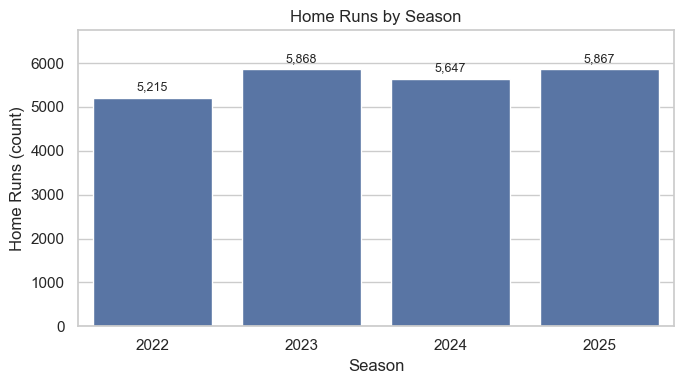

In [18]:
# Build season-level HR counts from at_bats_2022 ... at_bats_2025
rows = []
for y in range(2022, 2026):
    df = globals().get(f"at_bats_{y}")
    if df is None or "home_run" not in df.columns:
        print(f"at_bats_{y}: skipped (not loaded or missing 'home_run')")
        continue
    rows.append({"season": y, "home_runs": int(df["home_run"].sum())})

hr_counts = pd.DataFrame(rows).sort_values("season")

# Plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=hr_counts, x="season", y="home_runs",
            order=sorted(hr_counts["season"]), ax=ax)

ax.set_title("Home Runs by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Home Runs (count)")

# Add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:,.0f}",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points",
                fontsize=9)

# Add headroom for labels
ax.set_ylim(0, max(hr_counts["home_runs"]) * 1.15)

plt.tight_layout()
plt.show()


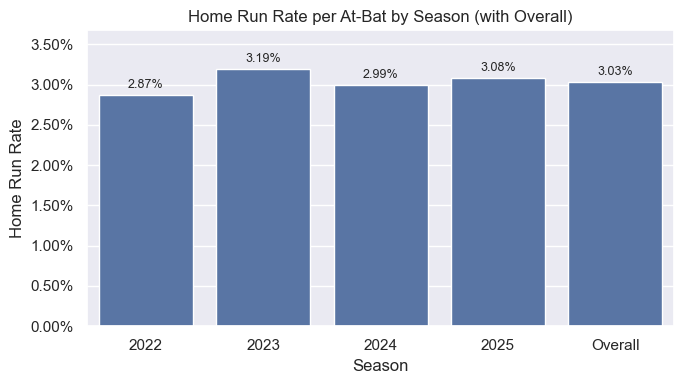

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Build season-level HR stats from at_bats_2022 ... at_bats_2025
rows = []
total_hr = 0
total_ab = 0

for y in range(2022, 2026):
    df = globals().get(f"at_bats_{y}")
    if df is None or "home_run" not in df.columns:
        print(f"at_bats_{y}: skipped (not loaded or missing 'home_run')")
        continue

    n_ab = len(df)
    n_hr = int(df["home_run"].sum())
    rows.append({"season": str(y), "home_runs": n_hr, "at_bats": n_ab,
                 "home_run_rate": n_hr / n_ab})

    total_hr += n_hr
    total_ab += n_ab

# Append weighted overall
rows.append({
    "season": "Overall",
    "home_runs": total_hr,
    "at_bats": total_ab,
    "home_run_rate": total_hr / total_ab if total_ab else 0.0
})

hr_rates = pd.DataFrame(rows)
order = ["2022", "2023", "2024", "2025", "Overall"]

# Plot
sns.set_theme()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=hr_rates, x="season", y="home_run_rate", order=order, ax=ax)

ax.set_title("Home Run Rate per At-Bat by Season (with Overall)")
ax.set_xlabel("Season")
ax.set_ylabel("Home Run Rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2%}",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points",
                fontsize=9)

# Optional headroom so labels don’t clip
ax.set_ylim(0, hr_rates["home_run_rate"].max() * 1.15)

plt.tight_layout()
plt.show()


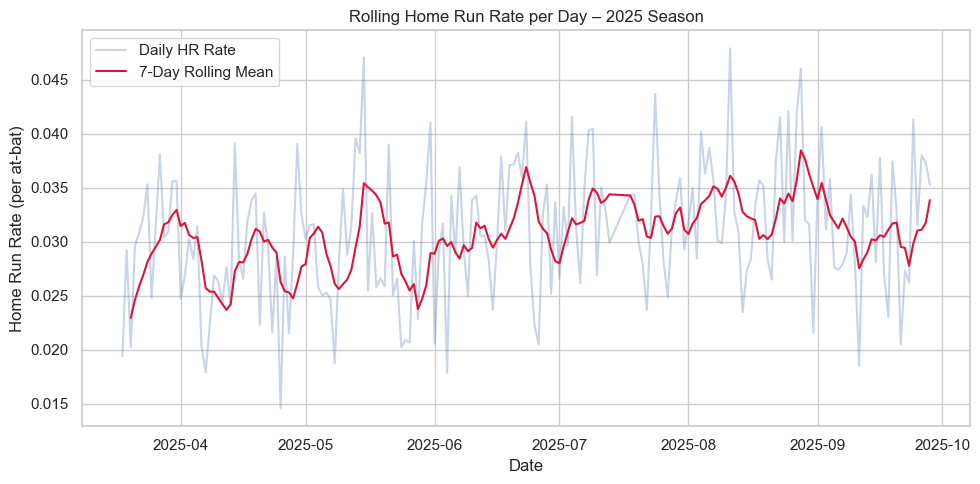

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pick one season, e.g. 2025
df = at_bats_2025.copy()

# Ensure game_date is datetime
df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")

# Daily HR rate = (# HR) / (total AB)
daily = df.groupby("game_date")["home_run"].mean().reset_index(name="daily_hr_rate")

# Rolling mean (7-day window)
daily["rolling_hr_rate"] = daily["daily_hr_rate"].rolling(7, min_periods=3).mean()

# Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
plt.plot(daily["game_date"], daily["daily_hr_rate"], alpha=0.3, label="Daily HR Rate")
plt.plot(daily["game_date"], daily["rolling_hr_rate"], color="crimson", label="7-Day Rolling Mean")
plt.title("Rolling Home Run Rate per Day – 2025 Season")
plt.xlabel("Date")
plt.ylabel("Home Run Rate (per at-bat)")
plt.legend()
plt.tight_layout()
plt.show()


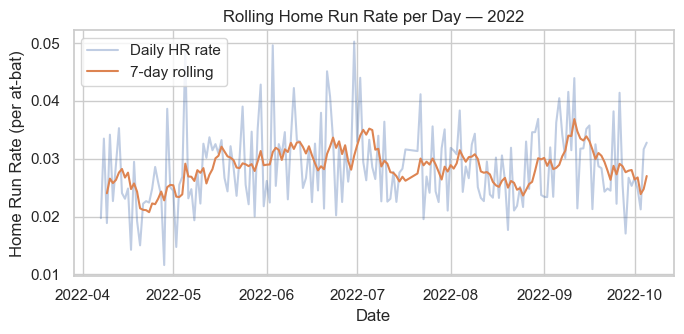

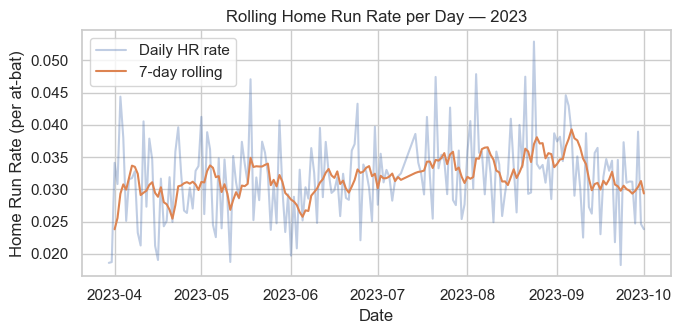

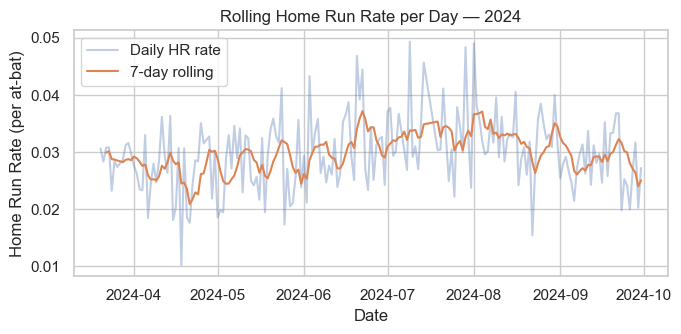

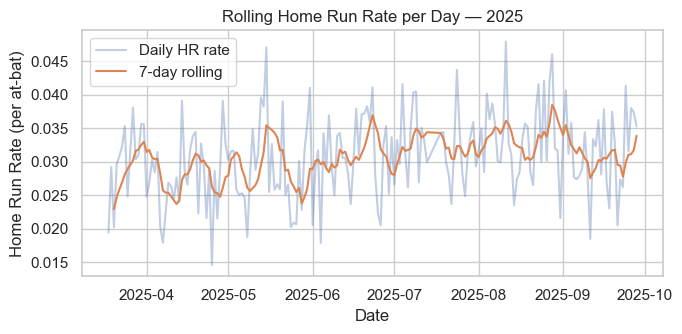

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# seasons to plot (adjust as you like)
seasons = [2022, 2023, 2024, 2025]

# rolling window (days)
WINDOW = 7

sns.set_theme(style="whitegrid")

# Optional: set a folder to save images (toggle save_figs True/False)
save_figs = False
out_dir = Path("data/plots_rolling_hr")
if save_figs:
    out_dir.mkdir(parents=True, exist_ok=True)

for y in seasons:
    df = globals().get(f"at_bats_{y}")
    if df is None or "home_run" not in df.columns or "game_date" not in df.columns:
        print(f"at_bats_{y}: skipped (not loaded or missing columns)")
        continue

    # ensure datetime
    if not pd.api.types.is_datetime64_any_dtype(df["game_date"]):
        df = df.copy()
        df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")

    # daily HR rate = HR / AB for that day
    daily = (
        df.groupby("game_date")["home_run"]
          .mean()
          .reset_index(name="daily_hr_rate")
          .sort_values("game_date")
    )
    daily["roll_hr_rate"] = daily["daily_hr_rate"].rolling(WINDOW, min_periods=3).mean()

    # make an individual plot per season
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(daily["game_date"], daily["daily_hr_rate"], alpha=0.35, label="Daily HR rate")
    ax.plot(daily["game_date"], daily["roll_hr_rate"], label=f"{WINDOW}-day rolling")

    ax.set_title(f"Rolling Home Run Rate per Day — {y}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Home Run Rate (per at-bat)")
    ax.legend(loc="upper left")
    plt.tight_layout()

    if save_figs:
        fig_path = out_dir / f"rolling_hr_rate_{y}.png"
        plt.savefig(fig_path, dpi=200)
        print(f"Saved: {fig_path}")

    plt.show()


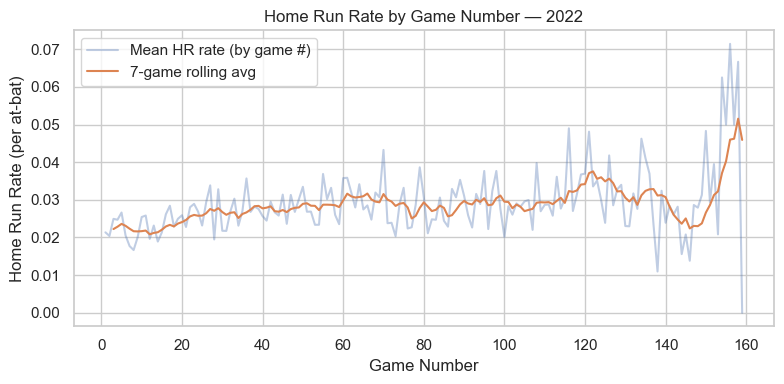

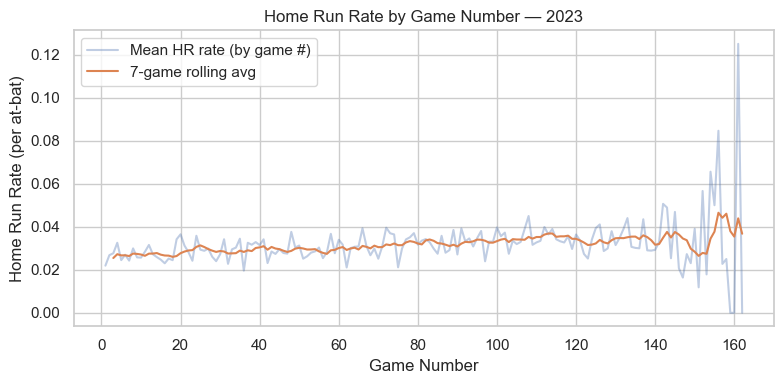

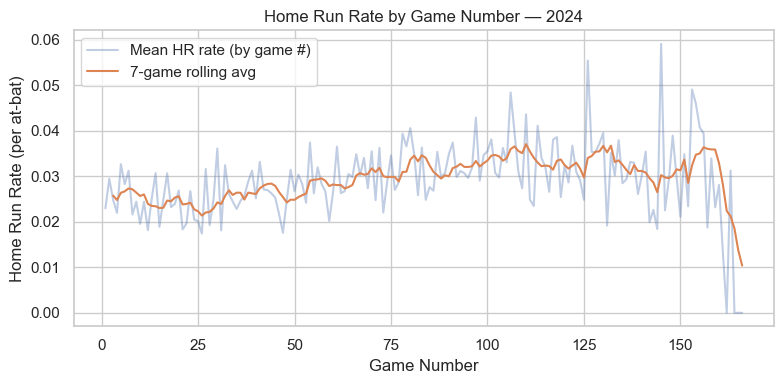

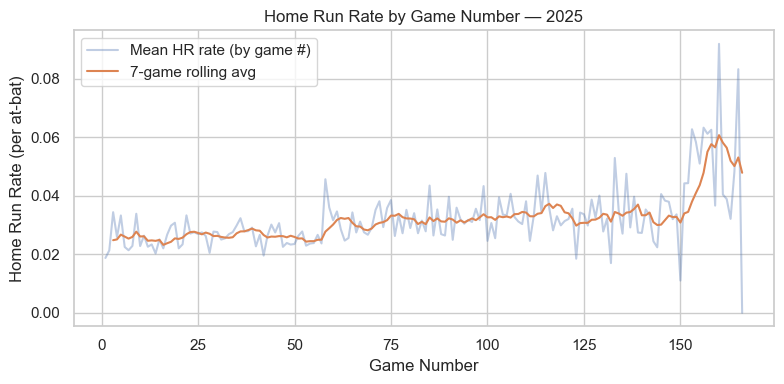

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

seasons = [2022, 2023, 2024, 2025]  # adjust as you like
ROLL_N = 7  # 7-game rolling average

for y in seasons:
    df = globals().get(f"at_bats_{y}")
    if df is None or not {"batter_id", "home_run", "game_date"}.issubset(df.columns):
        print(f"at_bats_{y}: skipped (not loaded or missing columns)")
        continue

    # Ensure datetime for ordering
    if not pd.api.types.is_datetime64_any_dtype(df["game_date"]):
        df = df.copy()
        df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")

    # Choose a per-game key (prefer unique game id if available)
    if "game_pk" in df.columns:
        game_key = ["game_pk"]
    elif "game_id" in df.columns:
        game_key = ["game_id"]
    else:
        # Fallback: date + teams (good enough for most; doubleheaders may share the date)
        game_key = [c for c in ["game_date", "home_team", "away_team"] if c in df.columns]

    # 1) Per-batter, per-game HR rate (mean of home_run across their ABs in that game)
    gb_cols = ["batter_id"] + game_key
    per_bg = (
        df.groupby(gb_cols, as_index=False)
          .agg(home_run_rate=("home_run", "mean"),
               game_date=("game_date", "first"))  # keep a date for ordering
    )

    # 2) Assign sequential game_number per batter (ordered by date, then game key)
    sort_cols = ["batter_id", "game_date"] + [c for c in game_key if c != "game_date"]
    per_bg = per_bg.sort_values(sort_cols, kind="mergesort")
    per_bg["game_number"] = per_bg.groupby("batter_id").cumcount() + 1

    # 3) Aggregate across batters at each game_number (league-wide view)
    per_gamen = (
        per_bg.groupby("game_number", as_index=False)["home_run_rate"]
              .mean()
              .rename(columns={"home_run_rate": "mean_hr_rate"})
              .sort_values("game_number")
    )

    # 4) 7-game rolling average over game_number
    per_gamen["rolling_mean_hr_rate"] = per_gamen["mean_hr_rate"].rolling(ROLL_N, min_periods=3).mean()

    # Plot for this season (separate figure)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(per_gamen["game_number"], per_gamen["mean_hr_rate"], alpha=0.35, label="Mean HR rate (by game #)")
    ax.plot(per_gamen["game_number"], per_gamen["rolling_mean_hr_rate"], label=f"{ROLL_N}-game rolling avg")
    ax.set_title(f"Home Run Rate by Game Number — {y}")
    ax.set_xlabel("Game Number")
    ax.set_ylabel("Home Run Rate (per at-bat)")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()
